<a href="https://colab.research.google.com/github/Jackline-Jebet/Streaming-Analytics-NLP-Pipeline-ML-/blob/main/Data_Streaming_analytics_using_PySpark_Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install required PySpark libraries
!pip install pyspark matplotlib seaborn scipy
# Import libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, explode, split, lower, regexp_replace
from pyspark.sql.types import StringType
import pyspark.sql.functions as F
from pyspark.sql.streaming import DataStreamWriter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy
import os
import time

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Create directories in Google Drive
!mkdir -p /content/drive/MyDrive/UEL_CN_7030/subsets
!mkdir -p /content/drive/MyDrive/UEL_CN_7030/output

In [ ]:
# Initialize Spark session
spark = SparkSession.builder.appName("Task2_StreamingAnalytics_14M").getOrCreate()

In [ ]:
# !cp /content/drive/MyDrive/UEL_CN_7030/subsets/*.txt /content/
# !ls -l /content/*.txt

-rw------- 1 root root 5885720 May 24 04:27 /content/subset_1000000.txt
-rw------- 1 root root  598782 May 24 04:27 /content/subset_100000.txt
-rw------- 1 root root   60881 May 24 04:27 /content/subset_10000.txt
-rw------- 1 root root    6223 May 24 04:27 /content/subset_1000.txt


In [ ]:
df = spark.read.csv("/content/drive/MyDrive/UEL_CN_7030/output/freq_100000.csv")
df.show()

+-----------+--------------------+--------------------+--------------------+
|        _c0|                 _c1|                 _c2|                 _c3|
+-----------+--------------------+--------------------+--------------------+
|      words|           true_freq|             gt_freq|             kn_freq|
|        few|3.054926125003397...|2.932139646830006E-4|3.601701316250408E-4|
|     formby|1.461337538867925...|6.467696936726112E-6|3.558552956526573...|
|  involving|4.566679808962266E-5| 4.46997001833345E-5|4.431416194721391...|
| lieutenant|8.329623971547174E-6|6.467696936726112E-6|3.558552956526573...|
|   priority|4.325559115049058...|5.370150831714097E-5|5.450306419488575E-5|
|requirement|3.361076339396228E-5|3.583842318583513E-5|3.412525969954208E-5|
|       some|0.001380671706722...|                 0.0|0.001511516085611...|
|      still|6.519757429659248E-4|3.209504208016628...|4.416813496064155E-4|
|      those|6.671005864932078E-4|8.558677888044342E-4|8.390485372656171E-4|

In [ ]:
# Step 1: Define file paths (Google Drive)
corpus_file = "/content/drive/MyDrive/UEL_CN_7030/corpus.txt"
subset_sizes = [1000, 10000, 100000, 1000000]  # Word counts for subsets
output_dir = "/content/drive/MyDrive/UEL_CN_7030/subsets/"

In [ ]:
# Function to create subset files
def create_subsets(corpus_file, sizes, output_dir):
    print("Creating subset files...")
    with open(corpus_file, 'r', encoding='utf-8') as f:
        text = f.read()
    words = text.split()
    print(f"Total words in corpus: {len(words)}")
    for size in sizes:
        subset_text = ' '.join(words[:size])
        with open(f"{output_dir}/subset_{size}.txt", 'w', encoding='utf-8') as f:
            f.write(subset_text)
        print(f"Created subset_{size}.txt with {size} words")
        print(f"Subset files created in {output_dir}")
        words = words[size:]

In [ ]:
# Create subsets (run once, then comment out)
# create_subsets(corpus_file, subset_sizes, output_dir)

Creating subset files...
Total words in corpus: 14063140
Created subset_1000.txt with 1000 words
Created subset_10000.txt with 10000 words
Created subset_100000.txt with 100000 words
Created subset_1000000.txt with 1000000 words


In [ ]:
# Step 2: Preprocess the reference corpus (14M words, batch mode)
print("Processing reference corpus...")
reference_df = spark.read.text(corpus_file)
reference_df = reference_df.withColumn("text", lower(col("value")))
reference_df = reference_df.withColumn("text", regexp_replace(col("text"), "[^a-zA-Z\s]", ""))
reference_words = reference_df.withColumn("words", explode(split(col("text"), "\s+")))
reference_freq = reference_words.groupBy("words").count().withColumnRenamed("count", "true_count")
total_words = reference_freq.agg(F.sum("true_count")).collect()[0][0]
unique_words = reference_freq.count()
reference_freq = reference_freq.withColumn("true_freq", col("true_count") / total_words)
print(f"Reference corpus stats: Total words = {total_words}, Unique words = {unique_words}")
reference_df.show(5)
reference_freq.show(5)
total_words = reference_freq.agg(F.sum("true_count")).collect()[0][0]
print(f"Total words in reference corpus: {total_words}")


Processing reference corpus...
Reference corpus stats: Total words = 13686092, Unique words = 229045
+--------------------+--------------------+
|               value|                text|
+--------------------+--------------------+
|The Fulton County...|the fulton county...|
|The jury further ...|the jury further ...|
|                    |                    |
|The September-Oct...|the septemberocto...|
|"Only a relative ...|only a relative h...|
+--------------------+--------------------+
only showing top 5 rows

+-----------+----------+--------------------+
|      words|true_count|           true_freq|
+-----------+----------+--------------------+
|       some|     18896|0.001380671706722...|
|   priority|       592|4.325559115049058...|
|      still|      8923|6.519757429659248E-4|
|requirement|       460|3.361076339396228E-5|
|     formby|         2|1.461337538867925...|
+-----------+----------+--------------------+
only showing top 5 rows

Total words in reference corpus: 136860

In [ ]:
# Step 3: Streaming pipeline with memory sink
# Clear local directory
!rm -f /content/*.txt

# Start streaming query
streaming_df = spark.readStream.text("/content/*.txt")
streaming_df = streaming_df.withColumn("text", lower(col("value")))
streaming_df = streaming_df.withColumn("text", regexp_replace(col("text"), "[^a-zA-Z\s]", ""))
streaming_words = streaming_df.withColumn("words", explode(split(col("text"), "\s+")))
streaming_freq = streaming_words.groupBy("words").count().withColumnRenamed("count", "raw_count")

print("Starting streaming query with memory sink...")
query = streaming_freq.writeStream.outputMode("complete").trigger(processingTime="5 seconds").format("memory").queryName("word_counts").start()

# Write files dynamically
import time
files = ["subset_1000.txt", "subset_10000.txt", "subset_100000.txt", "subset_1000000.txt"]
for file in files:
    print(f"Writing {file}...")
    with open(f"/content/drive/MyDrive/UEL_CN_7030/subsets/{file}", "r", encoding="utf-8") as f:
        content = f.read()
    with open(f"/content/{file}", "w", encoding="utf-8") as f:
        f.write(content)
    time.sleep(5)

Starting streaming query with memory sink...
Writing subset_1000.txt...
Writing subset_10000.txt...
Writing subset_100000.txt...
Writing subset_1000000.txt...


In [ ]:
# Monitor streaming output
start_time = time.time()
for i in range(10):
    time.sleep(1)
    print(f"Streaming query running... {i+1}/10 seconds")
    if i % 5 == 0:
        result_df = spark.sql("SELECT * FROM word_counts ORDER BY raw_count DESC LIMIT 5")
        result_df.show()
query.awaitTermination(10)
query.stop()
print(f"Streaming query output captured. (completed in {time.time() - start_time:.2f}s)")

Streaming query running... 1/10 seconds
+-----+---------+
|words|raw_count|
+-----+---------+
|  the|       89|
|   of|       37|
|  and|       27|
|   in|       21|
|   to|       21|
+-----+---------+

Streaming query running... 2/10 seconds
Streaming query running... 3/10 seconds
Streaming query running... 4/10 seconds
Streaming query running... 5/10 seconds
Streaming query running... 6/10 seconds
+-----+---------+
|words|raw_count|
+-----+---------+
|  the|     8094|
|   of|     3675|
|   to|     2753|
|  and|     2669|
|    a|     2641|
+-----+---------+

Streaming query running... 7/10 seconds
Streaming query running... 8/10 seconds
Streaming query running... 9/10 seconds
Streaming query running... 10/10 seconds
Streaming query output captured. (completed in 29.35s)


In [ ]:
# Step 4: Implement Good-Turing Smoothing
def good_turing_smoothing(freq_df, total_words):
    count_of_counts = freq_df.groupBy("raw_count").count().withColumnRenamed("count", "Nr")
    count_of_counts = count_of_counts.withColumn("r_plus_1", col("raw_count") + 1)
    count_of_counts = count_of_counts.join(
        count_of_counts.select("raw_count", "Nr").withColumnRenamed("raw_count", "r_plus_1").withColumnRenamed("Nr", "N_r_plus_1"),
        "r_plus_1", "left"
    )
    count_of_counts = count_of_counts.withColumn("adjusted_count",
        ((col("raw_count") + 1) * F.coalesce(col("N_r_plus_1"), F.lit(0)) / col("Nr")))
    gt_freq = freq_df.join(
        count_of_counts.select("raw_count", "adjusted_count"),
        "raw_count", "left"
    ).withColumn("gt_freq", col("adjusted_count") / total_words)
    return gt_freq

In [ ]:
# Step 5: Implement Kneser-Ney Smoothing
def kneser_ney_smoothing(freq_df, total_words):
    d = 0.75
    unique_words = freq_df.count()
    kn_freq = freq_df.withColumn("kn_count",
        F.when(col("raw_count") > 0, col("raw_count") - d + (d * unique_words / total_words)))
    kn_freq = kn_freq.withColumn("kn_freq", col("kn_count") / total_words)
    return kn_freq

In [ ]:
# Step 6: Apply smoothing and compare with reference
results = {}
print("Applying smoothing and evaluating subsets...")
for size in subset_sizes:
    try:
        print(f"Processing subset {size}...")
        subset_path = f"{output_dir}/subset_{size}.txt"
        subset_df = spark.read.text(subset_path)
        subset_df = subset_df.withColumn("text", lower(col("value")))
        subset_df = subset_df.withColumn("text", regexp_replace(col("text"), "[^a-zA-Z\s]", ""))
        subset_words = subset_df.withColumn("words", explode(split(col("text"), "\s+")))
        subset_freq = subset_words.groupBy("words").count().withColumnRenamed("count", "raw_count")
        total_subset_words = subset_freq.agg(F.sum("raw_count")).collect()[0][0]
        print(f"Subset {size} total words: {total_subset_words}")

        gt_freq = good_turing_smoothing(subset_freq, total_subset_words)
        kn_freq = kneser_ney_smoothing(subset_freq, total_subset_words)

        compare_df = reference_freq.join(
            gt_freq.select("words", "gt_freq"), "words", "left"
        ).join(
            kn_freq.select("words", "kn_freq"), "words", "left"
        ).fillna(0)

        mse_gt = compare_df.withColumn("error_gt", F.pow(col("true_freq") - col("gt_freq"), 2))
        mse_kn = compare_df.withColumn("error_kn", F.pow(col("true_freq") - col("kn_freq"), 2))
        mse_gt_val = mse_gt.agg(F.avg("error_gt")).collect()[0][0]
        mse_kn_val = mse_kn.agg(F.avg("error_kn")).collect()[0][0]

        compare_pd = compare_df.select("words", "true_freq", "gt_freq", "kn_freq").toPandas()
        kl_gt = entropy(compare_pd["true_freq"] + 1e-10, compare_pd["gt_freq"] + 1e-10)
        kl_kn = entropy(compare_pd["true_freq"] + 1e-10, compare_pd["kn_freq"] + 1e-10)

        results[size] = {"mse_gt": mse_gt_val, "mse_kn": mse_kn_val, "kl_gt": kl_gt, "kl_kn": kl_kn}
        print(f"Subset {size} results:")
        print(f"Good-Turing MSE: {mse_gt_val:.6f}, KL Divergence: {kl_gt:.4f}")
        print(f"Kneser-Ney MSE: {mse_kn_val:.6f}, KL Divergence: {kl_kn:.4f}")

        # Only print sample frequencies for the 100,000-word subset (for Table 2)
        if size == 100000:
            print(f"Sample frequencies for subset {size}:")
            print(compare_pd[["words", "true_freq", "gt_freq", "kn_freq"]].head(10))

        # Save frequencies to CSV for all subsets
        compare_df.select("words", "true_freq", "gt_freq", "kn_freq").limit(10).coalesce(1).write.mode("overwrite").option("header", "true").csv(f"/content/drive/MyDrive/UEL_CN_7030/output/freq_{size}")
    except Exception as e:
        print(f"Error processing subset {size}: {str(e)}")
        # If SparkContext is stopped, reinitialize and recompute reference_freq
        if "stopped SparkContext" in str(e):
            print("Reinitializing Spark session...")
            spark = SparkSession.builder.appName("Task2_StreamingAnalytics_14M").getOrCreate()
            print("Recomputing reference_freq from corpus.txt...")
            reference_df = spark.read.text(corpus_file)
            reference_df = reference_df.withColumn("text", lower(col("value")))
            reference_df = reference_df.withColumn("text", regexp_replace(col("text"), "[^a-zA-Z\s]", ""))
            reference_words = reference_df.withColumn("words", explode(split(col("text"), "\s+")))
            reference_freq = reference_words.groupBy("words").count().withColumnRenamed("count", "true_count")
            total_words = reference_freq.agg(F.sum("true_count")).collect()[0][0]
            reference_freq = reference_freq.withColumn("true_freq", col("true_count") / total_words)
            print(f"Recomputed reference_freq: Total words = {total_words}")
        continue

Applying smoothing and evaluating subsets...
Processing subset 1000...
Subset 1000 total words: 986
Subset 1000 results:
Good-Turing MSE: 0.000000, KL Divergence: 10.6198
Kneser-Ney MSE: 0.000000, KL Divergence: 7.6364
Processing subset 10000...
Subset 10000 total words: 9842
Subset 10000 results:
Good-Turing MSE: 0.000000, KL Divergence: 9.2026
Kneser-Ney MSE: 0.000000, KL Divergence: 4.4749
Processing subset 100000...
Subset 100000 total words: 98146
Subset 100000 results:
Good-Turing MSE: 0.000000, KL Divergence: 8.2736
Kneser-Ney MSE: 0.000000, KL Divergence: 1.9874
Sample frequencies for subset 100000:
          words     true_freq  gt_freq  kn_freq
0           aaa  5.406949e-06      0.0      0.0
1          aaaa  6.576019e-07      0.0      0.0
2         aaaaa  1.461338e-07      0.0      0.0
3       aaadhar  7.306688e-08      0.0      0.0
4         aaaee  7.306688e-08      0.0      0.0
5  aaaidnstable  7.306688e-08      0.0      0.0
6        aaammf  3.653344e-07      0.0      0.0
7

Generating visualizations...
Results dictionary: {1000: {'mse_gt': 3.218138349883409e-08, 'mse_kn': 1.396310758208969e-08, 'kl_gt': np.float64(10.619776754792872), 'kl_kn': np.float64(7.636409190845469)}, 10000: {'mse_gt': 3.1071400784791685e-08, 'mse_kn': 4.809370406697102e-09, 'kl_gt': np.float64(9.202623220509054), 'kl_kn': np.float64(4.4748662804573245)}, 100000: {'mse_gt': 3.149783528977085e-08, 'mse_kn': 2.9771746177700582e-09, 'kl_gt': np.float64(8.273559363158103), 'kl_kn': np.float64(1.9874360506649567)}, 1000000: {'mse_gt': 3.1629584704490794e-08, 'mse_kn': 3.2841003195663357e-09, 'kl_gt': np.float64(8.752034429270125), 'kl_kn': np.float64(1.3373413584233265)}}


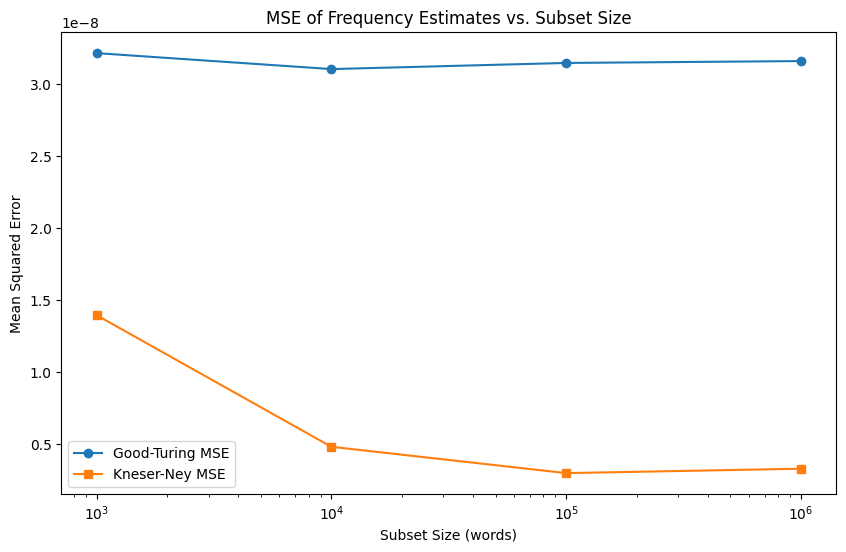

<Figure size 640x480 with 0 Axes>

In [ ]:
# Step 7: Visualizations
print("Generating visualizations...")
print("Results dictionary:", results)
if not results:
    print("Error: No results generated. Check subset processing.")
    spark.stop()
    raise ValueError("Results dictionary is empty")

plt.figure(figsize=(10, 6))
mse_gt_vals = [results[size]["mse_gt"] for size in subset_sizes]
mse_kn_vals = [results[size]["mse_kn"] for size in subset_sizes]
plt.plot(subset_sizes, mse_gt_vals, label="Good-Turing MSE", marker='o')
plt.plot(subset_sizes, mse_kn_vals, label="Kneser-Ney MSE", marker='s')
plt.xscale("log")
plt.xlabel("Subset Size (words)")
plt.ylabel("Mean Squared Error")
plt.title("MSE of Frequency Estimates vs. Subset Size")
plt.legend()
plt.show()
plt.savefig("/content/drive/MyDrive/UEL_CN_7030/output/mse_plot.png")

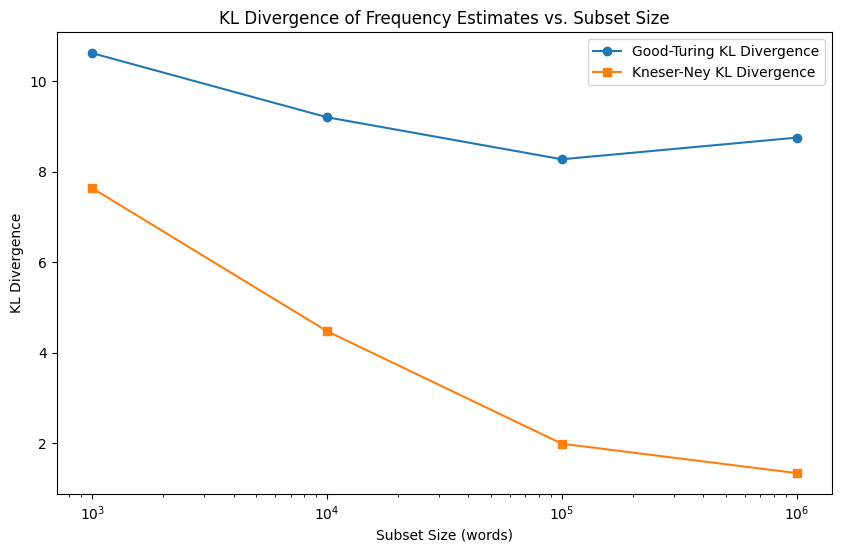

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(10, 6))
kl_gt_vals = [results[size]["kl_gt"] for size in subset_sizes]
kl_kn_vals = [results[size]["kl_kn"] for size in subset_sizes]
plt.plot(subset_sizes, kl_gt_vals, label="Good-Turing KL Divergence", marker='o')
plt.plot(subset_sizes, kl_kn_vals, label="Kneser-Ney KL Divergence", marker='s')
plt.xscale("log")
plt.xlabel("Subset Size (words)")
plt.ylabel("KL Divergence")
plt.title("KL Divergence of Frequency Estimates vs. Subset Size")
plt.legend()
plt.show()
plt.savefig("/content/drive/MyDrive/UEL_CN_7030/output/kl_plot.png")

Columns in freq_100000.csv:
Index(['words', 'true_freq', 'gt_freq', 'kn_freq'], dtype='object')
Sample data from freq_100000.csv:
         words              true_freq                gt_freq  \
0          few  3.0549261250033976E-4   2.932139646830006E-4   
1       formby  1.4613375388679252E-7   6.467696936726112E-6   
2    involving   4.566679808962266E-5    4.46997001833345E-5   
3   lieutenant   8.329623971547174E-6   6.467696936726112E-6   
4     priority  4.3255591150490584E-5   5.370150831714097E-5   
5  requirement   3.361076339396228E-5   3.583842318583513E-5   
6         some  0.0013806717067224158                    0.0   
7        still   6.519757429659248E-4  3.2095042080166285E-4   
8        those   6.671005864932078E-4   8.558677888044342E-4   
9       waters   2.557340693018869E-5   5.370150831714097E-5   

                 kn_freq  
0   3.601701316250408E-4  
1  3.5585529565265734E-6  
2  4.4314161947213916E-5  
3  3.5585529565265734E-6  
4   5.450306419488575E-5  
5  

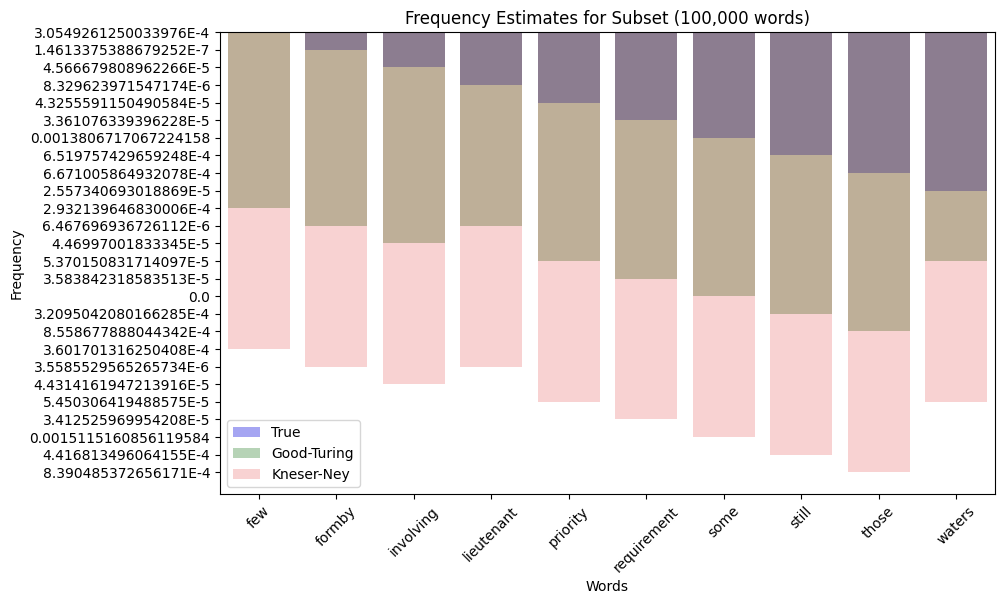

In [ ]:
# Load and verify CSV for 100,000-word subset
freq_100k = spark.read.option("header", "true").csv("/content/drive/MyDrive/UEL_CN_7030/output/freq_100000").toPandas()
print("Columns in freq_100000.csv:")
print(freq_100k.columns)
print("Sample data from freq_100000.csv:")
print(freq_100k.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x="words", y="true_freq", data=freq_100k, color="blue", alpha=0.4, label="True")
sns.barplot(x="words", y="gt_freq", data=freq_100k, color="green", alpha=0.3, label="Good-Turing")
sns.barplot(x="words", y="kn_freq", data=freq_100k, color="red", alpha=0.2, label="Kneser-Ney")
plt.xticks(rotation=45)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Frequency Estimates for Subset (100,000 words)")
plt.legend()
plt.savefig("/content/drive/MyDrive/UEL_CN_7030/output/freq_dist_100k.png")

In [ ]:
# Step 9:# Verify all outputs
!ls -l /content/drive/MyDrive/UEL_CN_7030/output/
df = spark.read.option("header", "true").csv("/content/drive/MyDrive/UEL_CN_7030/output/freq_1000000")
print(df.columns)
df.show(5)

total 163
drwx------ 2 root root  4096 May 24 06:12 freq_1000
drwx------ 2 root root  4096 May 24 06:13 freq_10000
drwx------ 2 root root  4096 May 24 06:14 freq_100000
drwx------ 2 root root  4096 May 24 06:16 freq_1000000
drwx------ 2 root root  4096 May 15 12:54 freq_1000000.csv
drwx------ 2 root root  4096 May 15 12:53 freq_100000.csv
drwx------ 2 root root  4096 May 15 12:52 freq_10000.csv
drwx------ 2 root root  4096 May 15 12:50 freq_1000.csv
-rw------- 1 root root 91691 May 24 06:16 freq_dist_100k.png
-rw------- 1 root root  2397 May 24 06:16 kl_plot.png
-rw------- 1 root root  2397 May 24 06:16 mse_plot.png
-rw------- 1 root root 36212 May 24 05:12 streaming_screenshot.png
['words', 'true_freq', 'gt_freq', 'kn_freq']
+----------+--------------------+--------------------+--------------------+
|     words|           true_freq|             gt_freq|             kn_freq|
+----------+--------------------+--------------------+--------------------+
|       few|3.054926125003397...|   

In [ ]:
spark.stop()